In [1]:
import pandas as pd
from typing import Tuple, List
import numpy as np
import os
from ruptures_simple.cost import CostL2
from ruptures_simple.search import BottomUp
from ruptures_simple.search.bottom_up import SegNode
from plot_utils import plot_seg_tree
import graphviz
from tree_utils import postorder_traverse,child_sort
import matplotlib.pyplot as plt
import matplotlib
font = {'size': 16}

matplotlib.rc('font', **font)

In [2]:
DATASET_PATH = "../../dataset"
INDEX_FIELD = "timestamp"
DATA_FIELD = "num_request"
TREE_IMG_ROOT="seg_tree"
CPD_IMG_ROOT="cpd_img"
CPD_CANDIDATE_ROOT="cpd_candidate"

In [3]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [4]:
def read_dataset(csv_path: str,index_field:str,data_field:str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path)
    return df[index_field].to_numpy(), df[data_field].to_numpy()

In [5]:
def save_tree_to_file(workload_name: str, graph: graphviz.Digraph):
    if not os.path.exists(TREE_IMG_ROOT):
        os.makedirs(TREE_IMG_ROOT)
    graph.attr(rankdir='TB')  # Set direction to top to bottom
    # graph.attr(splines="ortho")
    graph.render(os.path.join(TREE_IMG_ROOT, workload_name), format="pdf", cleanup=True)

In [6]:
# from exp_regression.train_utils import Trainer
# from exp_regression.evaluate_utils import Evaluator
# from exp_regression.dataset_utils import VanillaDataset, min_max_normalization
# from exp_regression.exp_model import ExpModel
# import torch.nn as nn
# import torch
# from torch.utils.data import DataLoader

# def exp_regression_sorted_gain(sorted_gain: np.ndarray):
#     gain_sum=np.sum(sorted_gain)
#     gain_cumsum=np.cumsum(sorted_gain)
#     sorted_gain=sorted_gain.reshape((-1,1))[10:25]
#     x = np.arange(1, len(sorted_gain)+1).reshape((-1, 1))
#     y, scaler = min_max_normalization(sorted_gain)
#     train_dataloader = DataLoader(VanillaDataset(x, y), batch_size=16, shuffle=False)
#     model = ExpModel()
#     optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)
#     # lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, SCHEDULER_MILESTONE, SCHEDULER_GAMMA)
#     lr_scheduler = None
#     loss_fn = nn.MSELoss()
#     trainer = Trainer(model, train_dataloader, loss_fn, optimizer, 1000, lr_scheduler, "cpu")
#     trainer.train()
#     train_evaluator = Evaluator(model, train_dataloader, loss_fn, "cpu")
#     train_evaluator.evaluate()
#     for name, param in model.named_parameters():
#         if param.requires_grad:
#             print(name, param.data)
#     fig,ax=plt.subplots()
#     ax.plot(scaler.inverse_transform(train_evaluator.get_gt()))
#     ax.plot(scaler.inverse_transform(train_evaluator.get_pd()))
#     plt.show()

In [7]:
def get_candidate_cpds(root: SegNode, np_data: np.ndarray):
    postorder_sequence, path_dict = postorder_traverse(root)
    end_set = set()
    end_set.add(len(np_data))
    cpd_set = set()
    for seg in postorder_sequence:
        if seg.cost > (seg.end-seg.start)*6250000:
            if seg.end in end_set:
                continue
            else:
                end_set.add(seg.end)
                cpd_set.add(seg.end)
    cpd_list = sorted([cpd for cpd in cpd_set])
    return cpd_list

In [8]:
def plot_cpd_result(candidate_cpds: List, np_data: np.ndarray, workload_name: str):
    color_workload, color_change = "#3F51B5", "#F44336"  # material red
    fig, ax = plt.subplots()
    fig.set_size_inches(16, 9)
    ax.plot(np.arange(len(np_data)), np_data/10, color=color_workload)
    for cp in candidate_cpds:
        ax.axvline(x=cp, color=color_change, linestyle='--', linewidth=1)
    ax.set_xlabel("time (min)")
    ax.set_ylabel("workload x (10 requests)")
    ax.set_title(workload_name)
    ax.grid(True)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # fig.legend()
    if not os.path.exists(CPD_IMG_ROOT):
        os.makedirs(CPD_IMG_ROOT)
    fig.savefig(CPD_IMG_ROOT+"/"+workload_name+".pdf")
    return fig, ax

In [9]:
import json


def save_candidate_cpds(candidate_cpds: List, workload_name: str):
    if not os.path.exists(CPD_CANDIDATE_ROOT):
        os.makedirs(CPD_CANDIDATE_ROOT)
    with open(os.path.join(CPD_CANDIDATE_ROOT, workload_name+".json"), "w") as f:
        json.dump(candidate_cpds, f, indent=4)
    plt.close()

run segment on workload_1998-06-10.csv
run segment on workload_1998-06-11.csv
run segment on workload_1998-06-12.csv
run segment on workload_1998-06-13.csv
run segment on workload_1998-06-14.csv
run segment on workload_1998-06-15.csv
run segment on workload_1998-06-16.csv
run segment on workload_1998-06-17.csv
run segment on workload_1998-06-18.csv
run segment on workload_1998-06-19.csv
run segment on workload_1998-06-20.csv
run segment on workload_1998-06-21.csv
run segment on workload_1998-06-22.csv
run segment on workload_1998-06-23.csv
run segment on workload_1998-06-24.csv
run segment on workload_1998-06-25.csv
run segment on workload_1998-06-26.csv
run segment on workload_1998-06-27.csv
run segment on workload_1998-06-28.csv
run segment on workload_1998-06-29.csv
run segment on workload_1998-06-30.csv
run segment on workload_1998-07-03.csv
run segment on workload_1998-07-04.csv
run segment on workload_1998-07-07.csv
run segment on workload_1998-07-08.csv


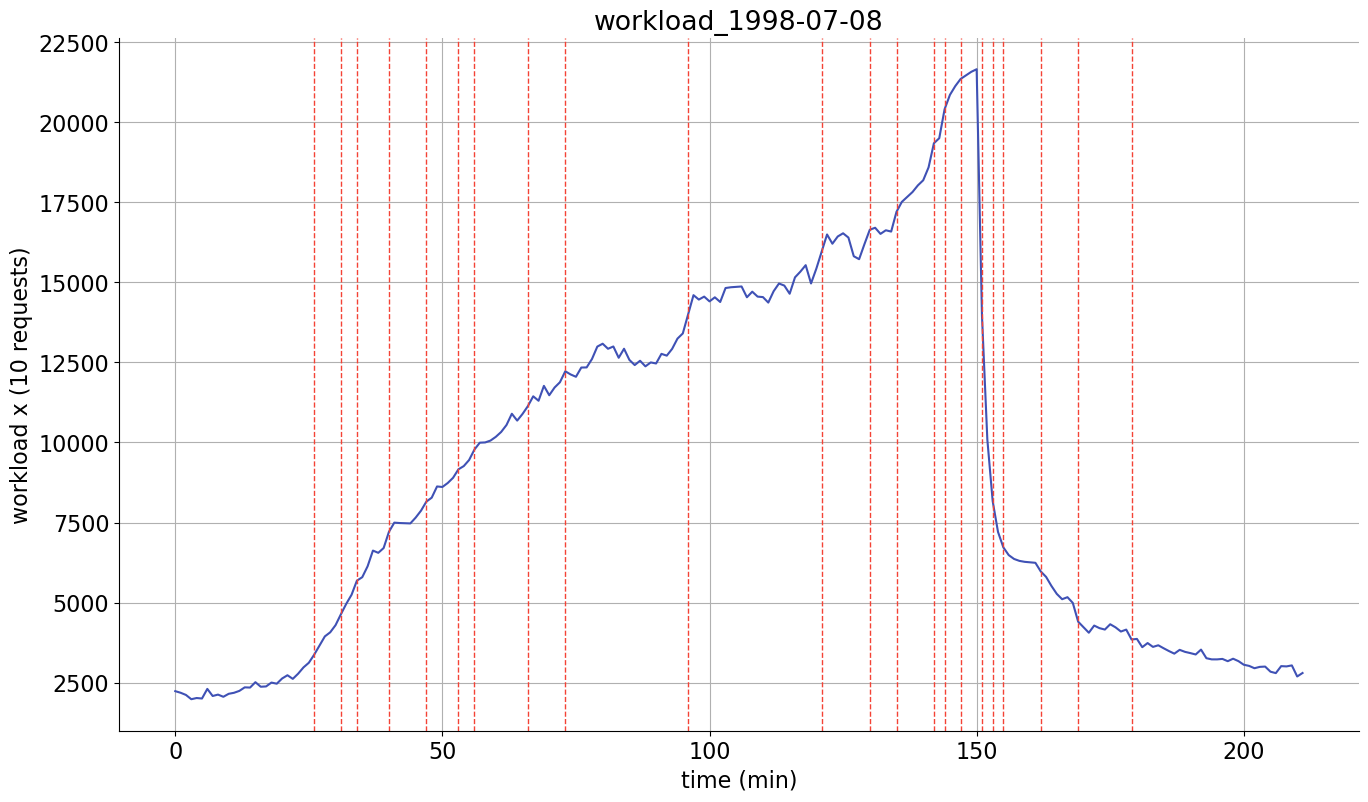

In [10]:
data_file_list = get_data_file_list(DATASET_PATH)
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    print("run segment on %s" % (file_name))
    np_index, np_data = read_dataset(os.path.join(DATASET_PATH, file_name), INDEX_FIELD, DATA_FIELD)
    np_data = np_data.reshape((-1, 1))
    algo = BottomUp(cost_model=CostL2(), init_seg_size=1)
    algo.fit(np_data)
    root_seg = algo.merge_search()
    child_sort(root_seg)
    graph = plot_seg_tree(root_seg)
    save_tree_to_file(workload_name, graph)
    candidate_cpds=get_candidate_cpds(root_seg,np_data)
    save_candidate_cpds(candidate_cpds,workload_name)
    plot_cpd_result(candidate_cpds,np_data,workload_name)
    # break